In [1]:
import pandas as pd
import numpy as np
import os 
from lifelines import CoxPHFitter
from lifelines.utils import concordance_index
from tqdm import tqdm
from scipy.stats import chi2
import matplotlib.pyplot as plt

### Loading and preparing the data

In [2]:
MAIN_DIR = "/home/joan/Desktop/PROJECTS/Glioblastomas/"
RESULTS = f"{MAIN_DIR}/RESULTS-GBM_4-cohorts_Tissues"
os.makedirs(f"{RESULTS}", exist_ok=True)
os.makedirs(f"{RESULTS}/Forest-plots_Cox-models", exist_ok=True)

daysXmonth = 365/12
voxel_size = (0.5**3) * (1/1000) # 0.5 (mm³/voxel) X 0.001 (cm³/mm³)   

In [3]:
def bootstrap_cindex(
        model, 
        data, 
        features,
        status="status",
        survival="OS (days) - corrected",
        n_bootstrap=1000, 
        alpha_CI=0.05,
        seed=42
    ):
    """Return (mean, lower 95% CI, upper 95% CI) of bootstrapped C-index."""
    rng = np.random.default_rng(seed)
    cindex_boot = []
    preds = model.predict_partial_hazard(data[features])
    for ib in tqdm(range(n_bootstrap), desc="Bootsrapping procedure"):
        idx = rng.integers(0, len(data), len(data))
        cidx = concordance_index(data[survival].values[idx], -preds.values[idx], data[status].values[idx])
        cindex_boot.append(cidx)
    cindex_boot = np.array(cindex_boot)
    lower = np.percentile(cindex_boot, 100 * (alpha_CI / 2))
    upper = np.percentile(cindex_boot, 100 * (1 - alpha_CI / 2))

    return (cindex_boot.mean(), lower, upper), cindex_boot


def llr_pvalue(ll_full, ll_reduced, df_diff):
    """Likelihood-ratio test p-value. df_diff = difference in free parameters."""
    lr_stat = 2 * (ll_full - ll_reduced)
    return chi2.sf(lr_stat, df=df_diff)


def print_model_summary(label, model, cindex_train, ci_boot):
    """Pretty-print log-HRs, HRs, p-values and CIs for one model."""
    print(f"\n{'═'*60}")
    print(f"  {label}")
    print(f"{'═'*60}")

    summary = model.summary  # lifelines DataFrame
    display_cols = ["exp(coef)", "coef", "exp(coef) lower 95%",
                    "exp(coef) upper 95%", "p"]
    rename = {
        "coef":                  "log-HR",
        "exp(coef)":             "HR",
        "exp(coef) lower 95%":  "HR CI lower",
        "exp(coef) upper 95%":  "HR CI upper",
        "p":                     "p-value",
    }
    out = summary[display_cols].rename(columns=rename)
    out["sig"] = out["p-value"].apply(
        lambda p: "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else ""))
    )

    with pd.option_context("display.float_format", "{:.8f}".format):
        print(out.to_string())

    print(f"\n  Train C-index : {cindex_train:.4f}")
    print(f"  Bootstrap C-index : {ci_boot[0]:.4f}  "
          f"(95% CI {ci_boot[1]:.4f} – {ci_boot[2]:.4f})")
    print(f"  Log-likelihood    : {model.log_likelihood_:.4f}")
    print(f"  AIC    : {model.AIC_partial_:.4f}")

In [4]:
data = pd.read_csv(f"{RESULTS}/data-clinical_TD-tissues_4-cohorts.csv", sep=",")
data["Enhancing size (cm3)"] = voxel_size * data["Enhancing size (voxels)"]

### Pre-surgical features

In [5]:
ltdi_whole_pre = data[["OS (days) - corrected", "status", "age", "sex", "Whole lesion TDMap"]].copy().dropna()

cph_1 = CoxPHFitter(baseline_estimation_method="breslow")
cph_1.fit(ltdi_whole_pre, duration_col="OS (days) - corrected", event_col="status")
cindex_1 = cph_1.score(ltdi_whole_pre, scoring_method="concordance_index")
ll_1 = cph_1.log_likelihood_
aic_1 = cph_1.AIC_partial_
ci_boot_1, dist_boot_1 = bootstrap_cindex(cph_1, ltdi_whole_pre, ["OS (days) - corrected", "status", "age", "sex", "Whole lesion TDMap"], status="status", survival="OS (days) - corrected", n_bootstrap=5000, alpha_CI=0.05, seed=42)
print_model_summary(f"Model 1 (age + sex + W.LTDI N={len(ltdi_whole_pre)})", cph_1, cindex_1, ci_boot_1)

Bootsrapping procedure: 100%|██████████| 5000/5000 [00:16<00:00, 296.20it/s]


════════════════════════════════════════════════════════════
  Model 1 (age + sex + W.LTDI N=999)
════════════════════════════════════════════════════════════
                           HR      log-HR  HR CI lower  HR CI upper    p-value  sig
covariate                                                                          
age                1.02552776  0.02520736   1.01893953   1.03215858 0.00000000  ***
sex                0.92705680 -0.07574045   0.80527014   1.06726210 0.29186239     
Whole lesion TDMap 1.09123946  0.08731417   1.04907527   1.13509830 0.00001406  ***

  Train C-index : 0.6279
  Bootstrap C-index : 0.6279  (95% CI 0.6070 – 0.6492)
  Log-likelihood    : -4769.9488
  AIC    : 9545.8976


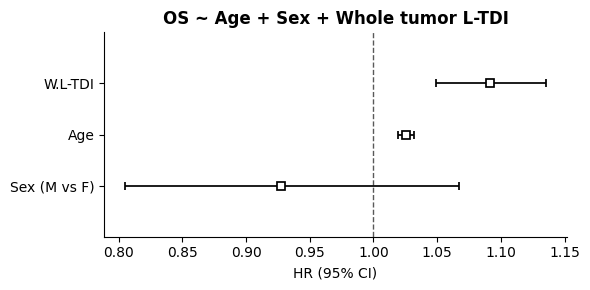

In [6]:
fig, ax = plt.subplots(figsize=(6, 3))
ax = cph_1.plot(hazard_ratios=True, ax=ax)
ax.set_yticklabels(["Sex (M vs F)", "Age", "W.L-TDI"])
ax.set_ylim([-1, 3])
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_title("OS ~ Age + Sex + Whole tumor L-TDI", fontweight="bold")
fig.tight_layout()
fig.savefig(f"{RESULTS}/Forest-plots_Cox-models/Presurgical_WLTDI.svg", dpi=200)

In [7]:
ltdi_enh_pre = data[["OS (days) - corrected", "status", "age", "sex", "Enhancing TDMap"]].copy().dropna()

cph_2 = CoxPHFitter(baseline_estimation_method="breslow")
cph_2.fit(ltdi_enh_pre, duration_col="OS (days) - corrected", event_col="status")
cindex_2 = cph_2.score(ltdi_enh_pre, scoring_method="concordance_index")
ll_2 = cph_2.log_likelihood_
aic_2 = cph_2.AIC_partial_
ci_boot_2, dist_boot_2 = bootstrap_cindex(cph_2, ltdi_enh_pre, ["OS (days) - corrected", "status", "age", "sex", "Enhancing TDMap"], status="status", survival="OS (days) - corrected", n_bootstrap=5000, alpha_CI=0.05, seed=42)
print_model_summary(f"Model 2 (age + sex + E.LTDI N={len(ltdi_enh_pre)})", cph_2, cindex_2, ci_boot_2)

Bootsrapping procedure: 100%|██████████| 5000/5000 [00:16<00:00, 296.53it/s]


════════════════════════════════════════════════════════════
  Model 2 (age + sex + E.LTDI N=995)
════════════════════════════════════════════════════════════
                        HR      log-HR  HR CI lower  HR CI upper    p-value  sig
covariate                                                                       
age             1.02711089  0.02674990   1.02048982   1.03377493 0.00000000  ***
sex             0.95000577 -0.05128722   0.82509861   1.09382194 0.47578892     
Enhancing TDMap 1.00325299  0.00324771   1.00203741   1.00447004 0.00000015  ***

  Train C-index : 0.6258
  Bootstrap C-index : 0.6257  (95% CI 0.6042 – 0.6475)
  Log-likelihood    : -4739.9185
  AIC    : 9485.8370


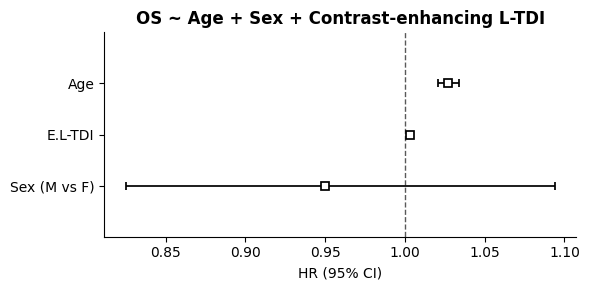

In [8]:
fig, ax = plt.subplots(figsize=(6, 3))
ax = cph_2.plot(hazard_ratios=True, ax=ax)
ax.set_yticklabels(["Sex (M vs F)", "E.L-TDI", "Age"])
ax.set_ylim([-1, 3])
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_title("OS ~ Age + Sex + Contrast-enhancing L-TDI", fontweight="bold")
fig.tight_layout()
fig.savefig(f"{RESULTS}/Forest-plots_Cox-models/Presurgical_ELTDI.svg", dpi=200)

In [9]:
vol_enh_pre = data[["OS (days) - corrected", "status", "age", "sex", "Enhancing size (cm3)"]].copy().dropna()

cph_3 = CoxPHFitter(baseline_estimation_method="breslow")
cph_3.fit(vol_enh_pre, duration_col="OS (days) - corrected", event_col="status")
cindex_3 = cph_3.score(vol_enh_pre, scoring_method="concordance_index")
ll_3 = cph_3.log_likelihood_
aic_3 = cph_3.AIC_partial_
ci_boot_3, dist_boot_3 = bootstrap_cindex(cph_3, vol_enh_pre, ["OS (days) - corrected", "status", "age", "sex", "Enhancing size (cm3)"], status="status", survival="OS (days) - corrected", n_bootstrap=5000, alpha_CI=0.05, seed=42)
print_model_summary(f"Model 3 (age + sex + E.size N={len(vol_enh_pre)})", cph_3, cindex_3, ci_boot_3)

Bootsrapping procedure: 100%|██████████| 5000/5000 [00:16<00:00, 296.63it/s]


════════════════════════════════════════════════════════════
  Model 3 (age + sex + E.size N=999)
════════════════════════════════════════════════════════════
                             HR      log-HR  HR CI lower  HR CI upper    p-value  sig
covariate                                                                            
age                  1.02576594  0.02543959   1.01917452   1.03239998 0.00000000  ***
sex                  0.93015583 -0.07240315   0.80801084   1.07076517 0.31343844     
Enhancing size (cm3) 1.00600421  0.00598626   1.00250332   1.00951733 0.00076366  ***

  Train C-index : 0.6195
  Bootstrap C-index : 0.6195  (95% CI 0.5979 – 0.6417)
  Log-likelihood    : -4773.9381
  AIC    : 9553.8762


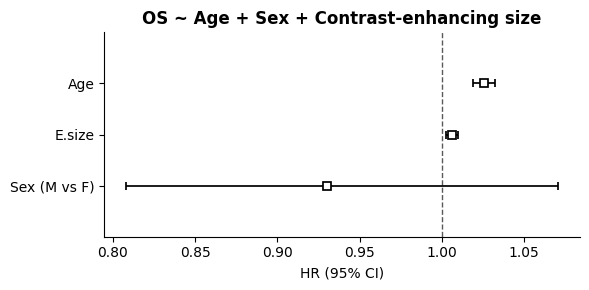

In [10]:
fig, ax = plt.subplots(figsize=(6, 3))
ax = cph_3.plot(hazard_ratios=True, ax=ax)
ax.set_yticklabels(["Sex (M vs F)", "E.size", "Age"])
ax.set_ylim([-1, 3])
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_title("OS ~ Age + Sex + Contrast-enhancing size", fontweight="bold")
fig.tight_layout()
fig.savefig(f"{RESULTS}/Forest-plots_Cox-models/Presurgical_Esize.svg", dpi=200)

In [11]:
pre = data[["OS (days) - corrected", "status", "age", "sex"]].copy().dropna()

cph_4 = CoxPHFitter(baseline_estimation_method="breslow")
cph_4.fit(pre, duration_col="OS (days) - corrected", event_col="status")
cindex_4 = cph_4.score(pre, scoring_method="concordance_index")
ll_4 = cph_4.log_likelihood_
aic_4 = cph_4.AIC_partial_
ci_boot_4, dist_boot_4 = bootstrap_cindex(cph_4, pre, ["OS (days) - corrected", "status", "age", "sex"], status="status", survival="OS (days) - corrected", n_bootstrap=5000, alpha_CI=0.05, seed=42)
print_model_summary(f"Model 4 (age + sex + mgmt + eor N={len(pre)})", cph_4, cindex_4, ci_boot_4)

Bootsrapping procedure: 100%|██████████| 5000/5000 [00:16<00:00, 305.06it/s]


════════════════════════════════════════════════════════════
  Model 4 (age + sex + mgmt + eor N=999)
════════════════════════════════════════════════════════════
                  HR      log-HR  HR CI lower  HR CI upper    p-value  sig
covariate                                                                 
age       1.02665515  0.02630609   1.02007373   1.03327903 0.00000000  ***
sex       0.93776179 -0.06425932   0.81471366   1.07939416 0.37057457     

  Train C-index : 0.6143
  Bootstrap C-index : 0.6144  (95% CI 0.5918 – 0.6366)
  Log-likelihood    : -4779.3964
  AIC    : 9562.7929


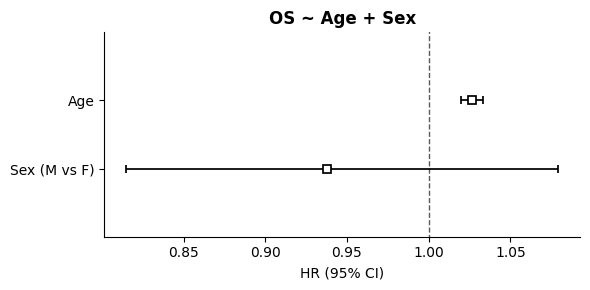

In [12]:
fig, ax = plt.subplots(figsize=(6, 3))
ax = cph_4.plot(hazard_ratios=True, ax=ax)
ax.set_yticklabels(["Sex (M vs F)", "Age"])
ax.set_ylim([-1, 2])
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_title("OS ~ Age + Sex", fontweight="bold")
fig.tight_layout()
fig.savefig(f"{RESULTS}/Forest-plots_Cox-models/Presurgical_base.svg", dpi=200)

In [13]:
print(f"AIC(age, sex, W.LTDI) - AIC(age, sex, E.LTDI) = {aic_1 - aic_2}")
print(f"AIC(age, sex, W.LTDI) - AIC(age, sex, E.size) = {aic_1 - aic_3}")
print(f"AIC(age, sex, W.LTDI) - AIC(age, sex) = {aic_1 - aic_4}")
print(f"AIC(age, sex, E.LTDI) - AIC(age, sex, E.size) = {aic_2 - aic_3}")
print(f"AIC(age, sex, E.LTDI) - AIC(age, sex) = {aic_2- aic_4}")
print(f"AIC(age, sex, E.size) - AIC(age, sex) = {aic_3 - aic_4}")

AIC(age, sex, W.LTDI) - AIC(age, sex, E.LTDI) = 60.06057349251569
AIC(age, sex, W.LTDI) - AIC(age, sex, E.size) = -7.978679720712535
AIC(age, sex, W.LTDI) - AIC(age, sex) = -16.89533056349501
AIC(age, sex, E.LTDI) - AIC(age, sex, E.size) = -68.03925321322822
AIC(age, sex, E.LTDI) - AIC(age, sex) = -76.9559040560107
AIC(age, sex, E.size) - AIC(age, sex) = -8.916650842782474


In [14]:
print(f"LLR(age, sex, W.LTDI; age, sex) = {llr_pvalue(ll_1, ll_4, df_diff=1)}")
print(f"LLR(age, sex, E.LTDI; age, sex) = {llr_pvalue(ll_2, ll_4, df_diff=1)}")
print(f"LLR(age, sex, E.size; age, sex) = {llr_pvalue(ll_3, ll_4, df_diff=1)}")

LLR(age, sex, W.LTDI; age, sex) = 1.380902625642139e-05
LLR(age, sex, E.LTDI; age, sex) = 6.3511845180909485e-19
LLR(age, sex, E.size; age, sex) = 0.0009530374993608371


### Post-surgical features

In [15]:
ltdi_whole_post = data[["OS (days) - corrected", "status", "age", "sex", "Whole lesion TDMap", "mgmt", "eor"]].copy().dropna()

cph_1 = CoxPHFitter(baseline_estimation_method="breslow")
cph_1.fit(ltdi_whole_post, duration_col="OS (days) - corrected", event_col="status")
cindex_1 = cph_1.score(ltdi_whole_post, scoring_method="concordance_index")
ll_1 = cph_1.log_likelihood_
aic_1 = cph_1.AIC_partial_
ci_boot_1, dist_boot_1 = bootstrap_cindex(cph_1, ltdi_whole_post, ["OS (days) - corrected", "status", "age", "sex", "Whole lesion TDMap", "mgmt", "eor"], status="status", survival="OS (days) - corrected", n_bootstrap=5000, alpha_CI=0.05, seed=42)
print_model_summary(f"Model 1 (age + sex + mgmt + eor +  W.LTDI N={len(ltdi_whole_post)})", cph_1, cindex_1, ci_boot_1)

Bootsrapping procedure: 100%|██████████| 5000/5000 [00:09<00:00, 514.97it/s]


════════════════════════════════════════════════════════════
  Model 1 (age + sex + mgmt + eor +  W.LTDI N=617)
════════════════════════════════════════════════════════════
                           HR      log-HR  HR CI lower  HR CI upper    p-value  sig
covariate                                                                          
age                1.02595898  0.02562776   1.01704447   1.03495163 0.00000001  ***
sex                0.96059049 -0.04020709   0.79559446   1.15980456 0.67583557     
Whole lesion TDMap 1.07847414  0.07554721   1.02552154   1.13416094 0.00327102   **
mgmt               0.74693607 -0.29177568   0.67842864   0.82236136 0.00000000  ***
eor                0.57285752 -0.55711824   0.48510845   0.67647912 0.00000000  ***

  Train C-index : 0.6697
  Bootstrap C-index : 0.6697  (95% CI 0.6429 – 0.6975)
  Log-likelihood    : -2508.7855
  AIC    : 5027.5709


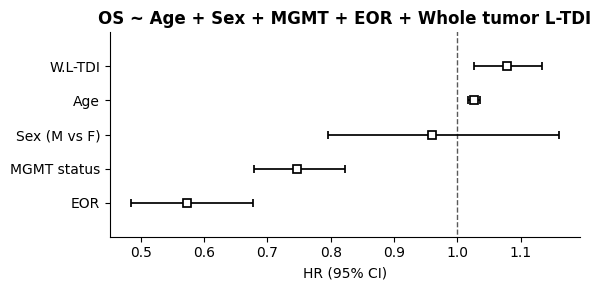

In [16]:
fig, ax = plt.subplots(figsize=(6, 3))
ax = cph_1.plot(hazard_ratios=True, ax=ax)
ax.set_yticklabels(["EOR", "MGMT status", "Sex (M vs F)", "Age", "W.L-TDI"])
ax.set_ylim([-1, 5])
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_title("OS ~ Age + Sex + MGMT + EOR + Whole tumor L-TDI", fontweight="bold")
fig.tight_layout()
fig.savefig(f"{RESULTS}/Forest-plots_Cox-models/Postsurgical_WLTDI.svg", dpi=200)

In [17]:
ltdi_enh_post = data[["OS (days) - corrected", "status", "age", "sex", "Enhancing TDMap", "mgmt", "eor"]].copy().dropna()

cph_2 = CoxPHFitter(baseline_estimation_method="breslow")
cph_2.fit(ltdi_enh_post, duration_col="OS (days) - corrected", event_col="status")
cindex_2 = cph_2.score(ltdi_enh_post, scoring_method="concordance_index")
ll_2 = cph_2.log_likelihood_
aic_2 = cph_2.AIC_partial_
ci_boot_2, dist_boot_2 = bootstrap_cindex(cph_2, ltdi_enh_post, ["OS (days) - corrected", "status", "age", "sex", "Enhancing TDMap", "mgmt", "eor"], status="status", survival="OS (days) - corrected", n_bootstrap=5000, alpha_CI=0.05, seed=42)
print_model_summary(f"Model 2 (age + sex + mgmt + eor +  E.LTDI N={len(ltdi_enh_post)})", cph_2, cindex_2, ci_boot_2)

Bootsrapping procedure: 100%|██████████| 5000/5000 [00:09<00:00, 512.22it/s]


════════════════════════════════════════════════════════════
  Model 2 (age + sex + mgmt + eor +  E.LTDI N=615)
════════════════════════════════════════════════════════════
                        HR      log-HR  HR CI lower  HR CI upper    p-value  sig
covariate                                                                       
age             1.02723945  0.02687506   1.01832695   1.03622996 0.00000000  ***
sex             0.99178429 -0.00824964   0.82145216   1.19743563 0.93161892     
Enhancing TDMap 1.00272304  0.00271933   1.00110867   1.00434001 0.00094031  ***
mgmt            0.74119941 -0.29948558   0.67275528   0.81660685 0.00000000  ***
eor             0.57132856 -0.55979083   0.48387947   0.67458189 0.00000000  ***

  Train C-index : 0.6663
  Bootstrap C-index : 0.6664  (95% CI 0.6384 – 0.6937)
  Log-likelihood    : -2495.6198
  AIC    : 5001.2396


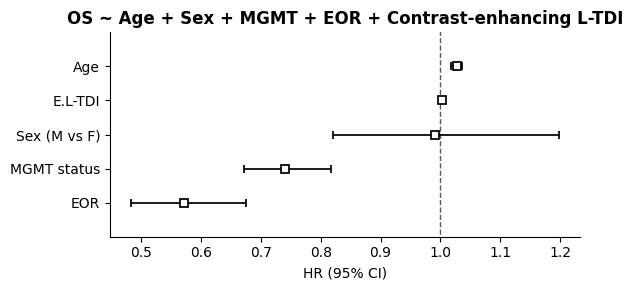

In [18]:
fig, ax = plt.subplots(figsize=(6, 3))
ax = cph_2.plot(hazard_ratios=True, ax=ax)
ax.set_yticklabels(["EOR", "MGMT status", "Sex (M vs F)", "E.L-TDI", "Age"])
ax.set_ylim([-1, 5])
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_title("OS ~ Age + Sex + MGMT + EOR + Contrast-enhancing L-TDI", fontweight="bold")
fig.tight_layout()
fig.savefig(f"{RESULTS}/Forest-plots_Cox-models/Postsurgical_ELTDI.svg", dpi=200)

In [19]:
vol_enh_post = data[["OS (days) - corrected", "status", "age", "sex", "Enhancing size (cm3)", "mgmt", "eor"]].copy().dropna()

cph_3 = CoxPHFitter(baseline_estimation_method="breslow")
cph_3.fit(vol_enh_post, duration_col="OS (days) - corrected", event_col="status")
cindex_3 = cph_3.score(vol_enh_post, scoring_method="concordance_index")
ll_3 = cph_3.log_likelihood_
aic_3 = cph_3.AIC_partial_
ci_boot_3, dist_boot_3 = bootstrap_cindex(cph_3, vol_enh_post, ["OS (days) - corrected", "status", "age", "sex", "Enhancing size (cm3)", "mgmt", "eor"], status="status", survival="OS (days) - corrected", n_bootstrap=5000, alpha_CI=0.05, seed=42)
print_model_summary(f"Model 3 (age + sex + mgmt + eor + E.size N={len(vol_enh_post)})", cph_3, cindex_3, ci_boot_3)

Bootsrapping procedure: 100%|██████████| 5000/5000 [00:09<00:00, 512.81it/s]


════════════════════════════════════════════════════════════
  Model 3 (age + sex + mgmt + eor + E.size N=617)
════════════════════════════════════════════════════════════
                             HR      log-HR  HR CI lower  HR CI upper    p-value  sig
covariate                                                                            
age                  1.02565787  0.02533423   1.01675512   1.03463857 0.00000001  ***
sex                  0.95031638 -0.05096031   0.78582918   1.14923351 0.59921298     
Enhancing size (cm3) 1.00634369  0.00632366   1.00157020   1.01113994 0.00914138   **
mgmt                 0.74371845 -0.29609274   0.67548290   0.81884699 0.00000000  ***
eor                  0.54691988 -0.60345296   0.46375847   0.64499384 0.00000000  ***

  Train C-index : 0.6656
  Bootstrap C-index : 0.6657  (95% CI 0.6385 – 0.6930)
  Log-likelihood    : -2509.8190
  AIC    : 5029.6379


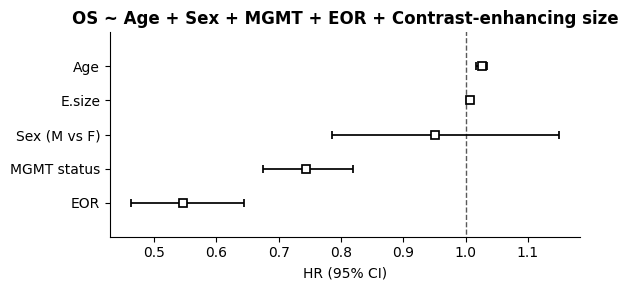

In [20]:
fig, ax = plt.subplots(figsize=(6, 3))
ax = cph_3.plot(hazard_ratios=True, ax=ax)
ax.set_yticklabels(["EOR", "MGMT status", "Sex (M vs F)", "E.size", "Age"])
ax.set_ylim([-1, 5])
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_title("OS ~ Age + Sex + MGMT + EOR + Contrast-enhancing size", fontweight="bold")
fig.tight_layout()
fig.savefig(f"{RESULTS}/Forest-plots_Cox-models/Postsurgical_Esize.svg", dpi=200)

In [21]:
post = data[["OS (days) - corrected", "status", "age", "sex", "mgmt", "eor"]].copy().dropna()

cph_4 = CoxPHFitter(baseline_estimation_method="breslow")
cph_4.fit(post, duration_col="OS (days) - corrected", event_col="status")
cindex_4 = cph_4.score(post, scoring_method="concordance_index")
ll_4 = cph_4.log_likelihood_
aic_4 = cph_4.AIC_partial_
ci_boot_4, dist_boot_4 = bootstrap_cindex(cph_4, post, ["OS (days) - corrected", "status", "age", "sex", "mgmt", "eor"], status="status", survival="OS (days) - corrected", n_bootstrap=5000, alpha_CI=0.05, seed=42)
print_model_summary(f"Model 4 (age + sex + mgmt + eor N={len(post)})", cph_4, cindex_4, ci_boot_4)

Bootsrapping procedure: 100%|██████████| 5000/5000 [00:09<00:00, 523.02it/s]


════════════════════════════════════════════════════════════
  Model 4 (age + sex + mgmt + eor N=617)
════════════════════════════════════════════════════════════
                  HR      log-HR  HR CI lower  HR CI upper    p-value  sig
covariate                                                                 
age       1.02631084  0.02597066   1.01745553   1.03524321 0.00000000  ***
sex       0.98677028 -0.01331801   0.81785618   1.19057067 0.88942715     
mgmt      0.74797445 -0.29038646   0.67923923   0.82366529 0.00000000  ***
eor       0.54856178 -0.60045536   0.46564324   0.64624589 0.00000000  ***

  Train C-index : 0.6616
  Bootstrap C-index : 0.6616  (95% CI 0.6340 – 0.6896)
  Log-likelihood    : -2513.0951
  AIC    : 5034.1902


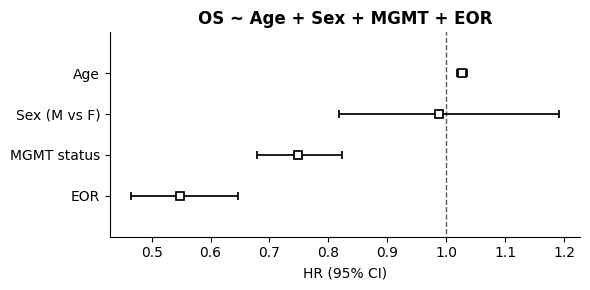

In [22]:
fig, ax = plt.subplots(figsize=(6, 3))
ax = cph_4.plot(hazard_ratios=True, ax=ax)
ax.set_yticklabels(["EOR", "MGMT status", "Sex (M vs F)", "Age"])
ax.set_ylim([-1, 4])
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_title("OS ~ Age + Sex + MGMT + EOR", fontweight="bold")
fig.tight_layout()
fig.savefig(f"{RESULTS}/Forest-plots_Cox-models/Postsurgical_base.svg", dpi=200)

In [23]:
print(f"AIC(age, sex, W.LTDI) - AIC(age, sex, E.LTDI) = {aic_1 - aic_2}")
print(f"AIC(age, sex, W.LTDI) - AIC(age, sex, E.size) = {aic_1 - aic_3}")
print(f"AIC(age, sex, W.LTDI) - AIC(age, sex) = {aic_1 - aic_4}")
print(f"AIC(age, sex, E.LTDI) - AIC(age, sex, E.size) = {aic_2 - aic_3}")
print(f"AIC(age, sex, E.LTDI) - AIC(age, sex) = {aic_2- aic_4}")
print(f"AIC(age, sex, E.size) - AIC(age, sex) = {aic_3 - aic_4}")

AIC(age, sex, W.LTDI) - AIC(age, sex, E.LTDI) = 26.331300683757036
AIC(age, sex, W.LTDI) - AIC(age, sex, E.size) = -2.067040934727629
AIC(age, sex, W.LTDI) - AIC(age, sex) = -6.619273161405545
AIC(age, sex, E.LTDI) - AIC(age, sex, E.size) = -28.398341618484665
AIC(age, sex, E.LTDI) - AIC(age, sex) = -32.95057384516258
AIC(age, sex, E.size) - AIC(age, sex) = -4.552232226677916


In [24]:
print(f"LLR(age, sex, W.LTDI; age, sex) = {llr_pvalue(ll_1, ll_4, df_diff=1)}")
print(f"LLR(age, sex, E.LTDI; age, sex) = {llr_pvalue(ll_2, ll_4, df_diff=1)}")
print(f"LLR(age, sex, E.size; age, sex) = {llr_pvalue(ll_3, ll_4, df_diff=1)}")

LLR(age, sex, W.LTDI; age, sex) = 0.003326245461275846
LLR(age, sex, E.LTDI; age, sex) = 3.3818171634671643e-09
LLR(age, sex, E.size; age, sex) = 0.010475265648125589
